This workshop assignment focuses on building, training, fine-tuning, and evaluating a Multilayer Perceptron (MLP) neural network on the MNIST dataset of handwritten digits.

# Workflow
1. Import the required libraries
2. Load the dataset
3. Inspect and understand the data
4. Prepare the data for training
5. Build and train a baseline Multilayer Perceptron model
6. Fine-tune the baseline Multilayer Perceptron model
7. Evaluate the final model on the test set

## 1. Import the required libraries


In [13]:
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

## 2. Load the dataset


In [14]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

## 3. Inspect and understand the data

- Check the Shape of the training and test sets
- Check the Target labels
- Check the class distribution
- Check for missing values
- Check the pixel value range
- Visualize a few samples


### Check the Shape of the training and test sets

In [15]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("\nX_train dtype:", X_train.dtype)
print("y_train dtype:", y_train.dtype)
print("X_test dtype:", X_test.dtype)
print("y_test dtype:", y_test.dtype)

print("\nX_train type:", type(X_train))
print("y_train type:", type(y_train))

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)

X_train dtype: uint8
y_train dtype: uint8
X_test dtype: uint8
y_test dtype: uint8

X_train type: <class 'numpy.ndarray'>
y_train type: <class 'numpy.ndarray'>


### Check the target labels

In [16]:
print("Unique labels in y_train:", np.unique(y_train))
print("Unique labels in y_test:", np.unique(y_test))

Unique labels in y_train: [0 1 2 3 4 5 6 7 8 9]
Unique labels in y_test: [0 1 2 3 4 5 6 7 8 9]


### Check the class distribution

In [17]:
print("Class distribution in y_train:")
unique, counts = np.unique(y_train, return_counts=True)
for label, count in zip(unique, counts):
    print(f"Digit {label}: {count}")

print("\nClass distribution in y_test:")
unique, counts = np.unique(y_test, return_counts=True)
for label, count in zip(unique, counts):
    print(f"Digit {label}: {count}")

Class distribution in y_train:
Digit 0: 5923
Digit 1: 6742
Digit 2: 5958
Digit 3: 6131
Digit 4: 5842
Digit 5: 5421
Digit 6: 5918
Digit 7: 6265
Digit 8: 5851
Digit 9: 5949

Class distribution in y_test:
Digit 0: 980
Digit 1: 1135
Digit 2: 1032
Digit 3: 1010
Digit 4: 982
Digit 5: 892
Digit 6: 958
Digit 7: 1028
Digit 8: 974
Digit 9: 1009


### Check for missing values

In [18]:
print("Missing values in X_train:", np.isnan(X_train).sum())
print("Missing values in y_train:", np.isnan(y_train).sum())

print("\nMissing values in X_test:", np.isnan(X_test).sum())
print("Missing values in y_test:", np.isnan(y_test).sum())

Missing values in X_train: 0
Missing values in y_train: 0

Missing values in X_test: 0
Missing values in y_test: 0


### Check the pixel value range

In [19]:
print("Minimum pixel value for X_train:", X_train.min())
print("Maximum pixel value for X_train:", X_train.max())
print("Mean pixel value for X_train:", X_train.mean())

print("\nMinimum pixel value for X_test:", X_test.min())
print("Maximum pixel value for X_test:", X_test.max())
print("Mean pixel value for X_test:", X_test.mean())

Minimum pixel value for X_train: 0
Maximum pixel value for X_train: 255
Mean pixel value for X_train: 33.318421449829934

Minimum pixel value for X_test: 0
Maximum pixel value for X_test: 255
Mean pixel value for X_test: 33.791224489795916


### Visualize a few samples

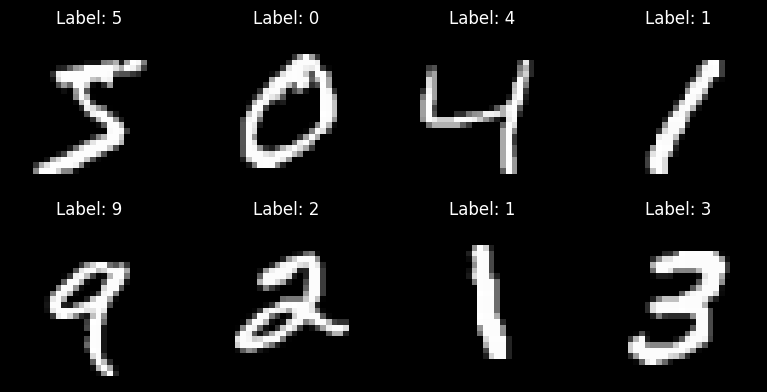

In [20]:
plt.figure(figsize=(8, 4))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

### Results
The inspection confirmed that the MNIST dataset contains 70,000 images in total, divided into 60,000 training images and 10,000 test images. Each image is represented as a 28 × 28 grayscale image, while the corresponding target variables contain one label per image. The labels represent the digit classes 0 to 9.

The class distribution was found to be reasonably balanced across all classes in both datasets, which indicates that the dataset is suitable for a classification task.

The feature values range from 0 to 255, where 0 corresponds to black and 255 corresponds to white, with intermediate values representing shades of gray. This is consistent with grayscale image data.

No missing values were detected in either the image arrays or the label arrays. In addition, the data was stored as NumPy arrays with the data type uint8, confirming that the dataset is already provided in a clean numerical format suitable for further preprocessing and model training.

## 4. Prepare the data for training
- Convert pixel values to float32 and normalize them
- Flatten the images into one-dimensional feature vectors

### Convert pixel values to float32 and normalize them

In [21]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("X_train dtype after normalization:", X_train.dtype)
print("X_test dtype after normalization:", X_test.dtype)

print("\nMinimum pixel value in X_train:", X_train.min())
print("Maximum pixel value in X_train:", X_train.max())
print("Minimum pixel value in X_test:", X_test.min())
print("Maximum pixel value in X_test:", X_test.max())

X_train dtype after normalization: float32
X_test dtype after normalization: float32

Minimum pixel value in X_train: 0.0
Maximum pixel value in X_train: 1.0
Minimum pixel value in X_test: 0.0
Maximum pixel value in X_test: 1.0


### Flatten the images into one-dimensional feature vectors

In [22]:
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

print("X_train shape after flattening:", X_train.shape)
print("X_test shape after flattening:", X_test.shape)

X_train shape after flattening: (60000, 784)
X_test shape after flattening: (10000, 784)


### Results

The pixel values were converted from **uint8** to **float32** and normalized to the range **[0, 1]**. After that, each **28 × 28 image** was flattened into a one-dimensional vector of length **784**, which matches the input format required by a Multilayer Perceptron.

## 5. Build and train a baseline Multilayer Perceptron model
- Build a baseline MLP model
- Compile the model
- Train the baseline model
- Evaluate the base model

### Build a baseline MLP model

In [23]:
baseline_mlp = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

In [25]:
baseline_mlp.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

### Compile the model

In [24]:
baseline_mlp.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### Train the baseline model

In [26]:
history = baseline_mlp.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9224 - loss: 0.2729 - val_accuracy: 0.9643 - val_loss: 0.1279
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 941us/step - accuracy: 0.9628 - loss: 0.1249 - val_accuracy: 0.9760 - val_loss: 0.0894
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 933us/step - accuracy: 0.9744 - loss: 0.0850 - val_accuracy: 0.9768 - val_loss: 0.0820
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 931us/step - accuracy: 0.9813 - loss: 0.0619 - val_accuracy: 0.9772 - val_loss: 0.0783
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 997us/step - accuracy: 0.9844 - loss: 0.0487 - val_accuracy: 0.9768 - val_loss: 0.0793
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 950us/step - accuracy: 0.9875 - loss: 0.0384 - val_accuracy: 0.9783 - val_loss: 0.0766
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9907 - loss: 0.0299 - val_accuracy: 0.9792 - val_loss: 0.0749
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9926 - loss:

### Evaluate the base model

In [32]:
print(history.params)
print(history.epoch)
history.history.keys()

{'verbose': 1, 'epochs': 10, 'steps': 1688}
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

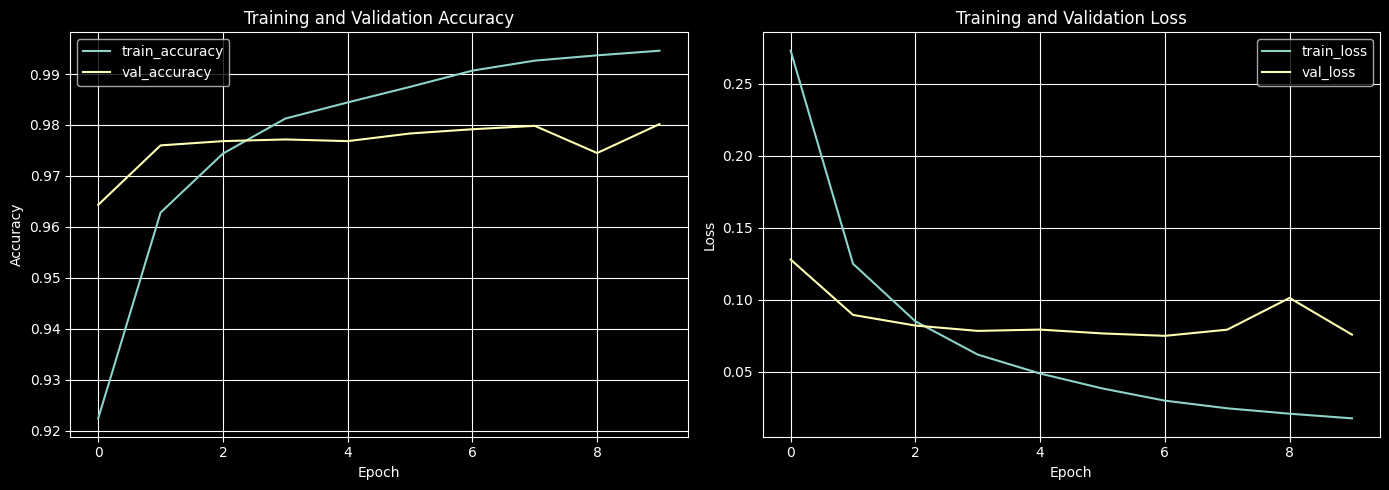

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history.history["accuracy"], label="train_accuracy")
axes[0].plot(history.history["val_accuracy"], label="val_accuracy")
axes[0].set_title("Training and Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].grid(True)
axes[0].legend()

# Loss plot
axes[1].plot(history.history["loss"], label="train_loss")
axes[1].plot(history.history["val_loss"], label="val_loss")
axes[1].set_title("Training and Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

### Results
The baseline Multilayer Perceptron consisted of an input layer for **784 features**, one hidden dense layer with **128 neurons** and ReLU activation, and an output layer with **10 neurons** and softmax activation. The model contained a total of **101,770 trainable parameters**.

The model was compiled using the Adam optimizer, sparse categorical cross-entropy loss, and accuracy as the evaluation metric. It was then trained for **10 epochs** with a **batch size of 32** and a v**alidation split of 0.1**.

During training, the model showed steady improvement across epochs. The training accuracy increased from approximately **0.922** in the first epoch to about **0.995** in the final epoch, while the training loss decreased from about **0.273 to 0.018**. The validation accuracy also remained high throughout training and reached about **0.980** at the end of training. At the same time, the validation loss stayed relatively low, finishing at about **0.076**.

The training and validation curves show that the model learned the digit classification task effectively. Training accuracy increased consistently, and training loss decreased steadily, which indicates that the model successfully fitted the training data. Validation accuracy remained close to training accuracy for most epochs, suggesting that the model generalized well to unseen validation data.

Overall, the baseline MLP achieved good performance on the MNIST dataset and provides a solid starting point for further fine-tuning and final evaluation on the test set.

## 6. Fine-tune the baseline Multilayer Perceptron model

### Results

## 7. Evaluate the final model on the test set

### Results
